# Liquidity and Order Book Depth

Order flow in financial markets often exhibits persistence.

However, price returns remain close to a random walk.

This raises an important question:

Why does persistent order flow not generate strong price trends?

The answer lies in **market liquidity**.

In this notebook we explore:

- the structure of the limit order book
- the concept of market depth
- how liquidity absorbs order flow
- how trade size affects price impact

## Import Simulation Components

Chúng ta sử dụng các module đã xây dựng trong package để mô phỏng limit order book và liquidity dynamics.

Các thành phần chính:

- OrderBook
- LiquidityModel
- MarketMaker
- MarketSimulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from src.structure import (
    OrderBook,
    LiquidityModel,
    MarketMaker,
    RandomOrderFlow,
    MarketSimulation
)

## Limit Order Book Structure

Limit order book chứa các lệnh mua và bán
tại nhiều mức giá khác nhau.

Hai phía của order book:

- **bid side** : các lệnh mua
- **ask side** : các lệnh bán

Best prices:

$$
P_{bid} = \max(\text{bid prices})
$$

$$
P_{ask} = \min(\text{ask prices})
$$

Mid price:

$$
P_{mid} = \frac{P_{bid} + P_{ask}}{2}
$$

Spread:

$$
spread = P_{ask} - P_{bid}
$$

In [2]:
orderbook = OrderBook()

mid = 100

for i in range(1,6):

    orderbook.add_bid(mid-i,100)
    orderbook.add_ask(mid+i,100)

orderbook.snapshot()

{'bids': {99.0: 100.0, 98.0: 100.0, 97.0: 100.0, 96.0: 100.0, 95.0: 100.0},
 'asks': {101.0: 100.0,
  102.0: 100.0,
  103.0: 100.0,
  104.0: 100.0,
  105.0: 100.0},
 'best_bid': 99.0,
 'best_ask': 101.0,
 'mid_price': 100.0}

## Order Book Snapshot

Snapshot trên cho thấy trạng thái hiện tại của **limit order book**.

Bid side chứa các lệnh mua (buy limit orders)
Ask side chứa các lệnh bán (sell limit orders).

Trong order book này:

- Best bid:

$$
P_{bid} = 99
$$

- Best ask:

$$
P_{ask} = 101
$$

Spread được định nghĩa:

$$
spread = P_{ask} - P_{bid}
$$

nên:

$$
spread = 101 - 99 = 2
$$

Mid price được tính bằng trung bình của best bid và best ask:

$$
P_{mid} = \frac{P_{bid} + P_{ask}}{2}
$$

Do đó:

$$
P_{mid} = \frac{99 + 101}{2} = 100
$$

### Interpretation

Order book này cho thấy liquidity được phân bố
ở nhiều mức giá xung quanh mid price.

- Người mua sẵn sàng mua ở giá ≤ 99
- Người bán sẵn sàng bán ở giá ≥ 101

Khoảng giữa hai mức giá này chính là **bid–ask spread**.

Cấu trúc liquidity như vậy cho phép thị trường
hấp thụ các giao dịch nhỏ mà không gây biến động giá lớn.

### Microstructure Insight

Khi một **market buy order** xuất hiện,
nó sẽ tiêu thụ liquidity ở phía ask.

Ngược lại, một **market sell order**
sẽ tiêu thụ liquidity ở phía bid.

Nếu khối lượng giao dịch đủ lớn,
nó có thể đi qua nhiều mức giá trong order book,
từ đó tạo ra **price impact**.

## Order Book Depth

Depth biểu diễn lượng liquidity
tại các mức giá khác nhau trong order book.

Liquidity càng lớn,
thị trường càng có khả năng hấp thụ giao dịch lớn
mà không gây biến động giá mạnh.

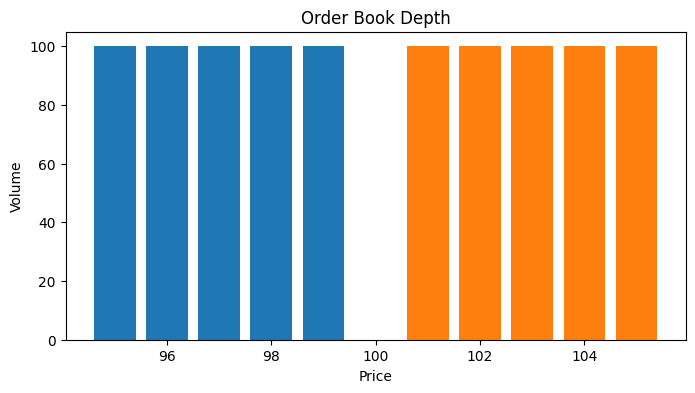

In [3]:
bids = orderbook.bid_levels()
asks = orderbook.ask_levels()

bid_prices = [p for p,_ in bids]
bid_volumes = [v for _,v in bids]

ask_prices = [p for p,_ in asks]
ask_volumes = [v for _,v in asks]

plt.figure(figsize=(8,4))

plt.bar(bid_prices,bid_volumes)
plt.bar(ask_prices,ask_volumes)

plt.xlabel("Price")
plt.ylabel("Volume")

plt.title("Order Book Depth")

plt.show()

## Order Book Depth Visualization

Biểu đồ trên thể hiện **liquidity distribution**
trong limit order book.

Mỗi cột biểu diễn lượng volume
tại một mức giá cụ thể.

Phía bên trái là **bid side** (lệnh mua),
phía bên phải là **ask side** (lệnh bán).

### Observations

Từ biểu đồ có thể quan sát:

- Liquidity được phân bố tại nhiều mức giá
xung quanh mid price.
- Mỗi price level trong ví dụ này có volume giống nhau.
- Bid liquidity nằm dưới mid price,
trong khi ask liquidity nằm phía trên.

Trong ví dụ này:

- Bid levels: 95 → 99
- Ask levels: 101 → 105

Mid price nằm giữa:

$$
P_{mid} = 100
$$

### Interpretation

Order book depth phản ánh khả năng
của thị trường trong việc hấp thụ giao dịch.

Nếu depth lớn:

- thị trường có nhiều liquidity
- các giao dịch nhỏ sẽ có **price impact thấp**

Ngược lại, nếu depth nhỏ:

- thị trường trở nên **thin**
- price impact của mỗi giao dịch sẽ lớn hơn.

### Microstructure Insight

Limit order book hoạt động như một **buffer**
giữa order flow và price dynamics.

Market orders sẽ tiêu thụ liquidity
tại các mức giá hiện có trong order book.

Do đó cấu trúc depth của order book
đóng vai trò quan trọng trong việc
quyết định **price impact của giao dịch**.

## Cumulative Depth Curve

Depth thường được phân tích bằng **cumulative liquidity**.

Đường cong này cho thấy tổng liquidity
khi đi xa dần khỏi mid price.

Trong thị trường thực,
liquidity thường tăng dần
khi distance from mid price tăng.

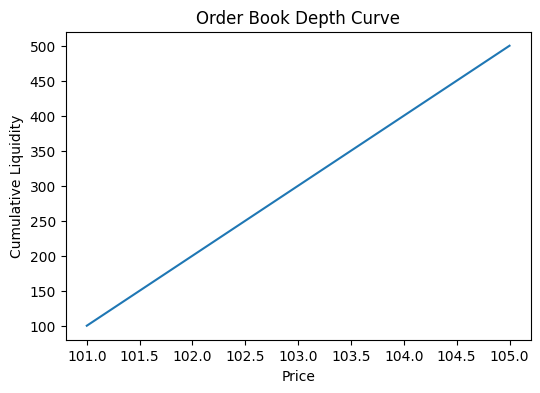

In [4]:
asks = orderbook.ask_levels()

prices=[]
depth=[]

cum=0

for p,v in asks:

    cum+=v

    prices.append(p)
    depth.append(cum)

plt.figure(figsize=(6,4))

plt.plot(prices,depth)

plt.xlabel("Price")
plt.ylabel("Cumulative Liquidity")

plt.title("Order Book Depth Curve")

plt.show()

## Order Book Depth Curve

Biểu đồ trên thể hiện cumulative liquidity
trên phía ask side của order book.

Trong ví dụ này, mỗi price level
có cùng lượng volume.

Do đó cumulative depth tăng tuyến tính
khi di chuyển xa khỏi mid price.

Trong thị trường thực, depth curve
thường có dạng convex,
với liquidity tăng nhanh
khi distance from mid price tăng.

Điều này phản ánh hành vi của liquidity providers,
những người thường đặt nhiều limit orders
ở các mức giá xa hơn để giảm rủi ro adverse selection.

## Liquidity and Market Orders

Market orders được thực thi
bằng cách **tiêu thụ liquidity trong order book**.

Ví dụ:

- market buy → consume ask liquidity
- market sell → consume bid liquidity

Nếu trade size lớn,
nó có thể đi qua nhiều mức giá trong order book.

Điều này tạo ra **price impact**.

## Trade Size and Price Impact

Một quan sát quan trọng trong microstructure:

Trade size lớn hơn thường gây price impact lớn hơn.

$$
\Delta P = f(Q)
$$

Trong đó:

- $Q$ : trade size
- $\Delta P$ : price change

In [5]:
orderbook = OrderBook()

liquidity = LiquidityModel()

market_maker = MarketMaker()

order_flow = RandomOrderFlow()

sim = MarketSimulation(
    orderbook,
    liquidity,
    market_maker,
    order_flow
)

In [6]:
result = sim.run(steps=5000)

prices = result["prices"]
trades = result["trades"]

## Trade Size vs Price Impact

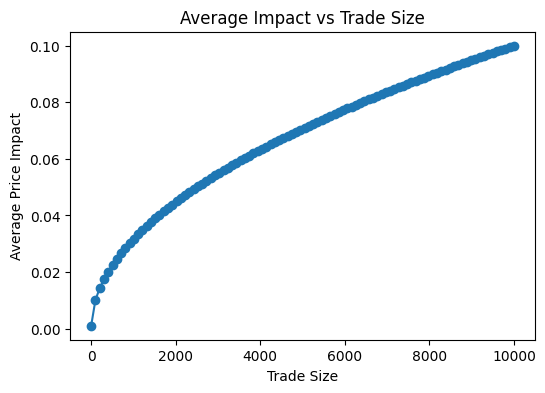

In [11]:
import pandas as pd

df = pd.DataFrame({
    "size": sizes,
    "impact": impacts
})

avg_impact = df.groupby("size")["impact"].mean()

plt.figure(figsize=(6,4))

plt.plot(avg_impact.index, avg_impact.values, marker="o")

plt.xlabel("Trade Size")
plt.ylabel("Average Price Impact")

plt.title("Average Impact vs Trade Size")

plt.show()

## Slippage vs Trade Size

Slippage đo chi phí thực thi giao dịch.

$$
slippage = execution\ price - mid\ price
$$

Trade size lớn hơn thường dẫn tới slippage lớn hơn.

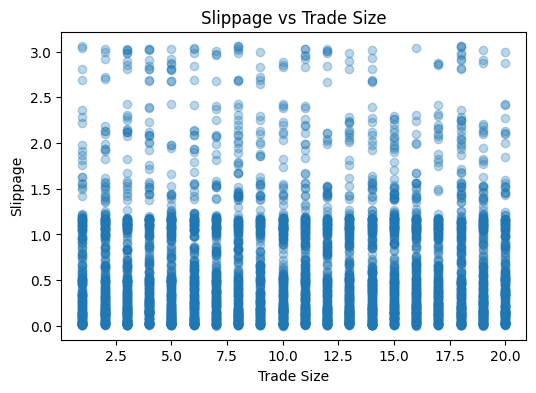

In [8]:
slippage=[]
sizes=[]

mid=np.mean(prices)

for t in trades:

    sizes.append(t["size"])
    slippage.append(abs(t["price"]-mid))

plt.figure(figsize=(6,4))

plt.scatter(sizes,slippage,alpha=0.3)

plt.xlabel("Trade Size")
plt.ylabel("Slippage")

plt.title("Slippage vs Trade Size")

plt.show()

## Square Root Impact Law

Empirical studies show that price impact
often follows the **square-root law**:

$$
\Delta P \propto \sqrt{Q}
$$

Điều này có nghĩa:

large trades có impact lớn,
nhưng không tăng tuyến tính với trade size.

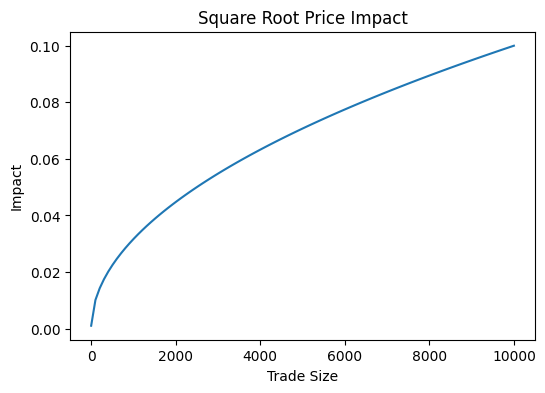

In [9]:
sizes=np.linspace(1,10000,100)

impacts=[liquidity.square_root_impact(s) for s in sizes]

plt.figure(figsize=(6,4))

plt.plot(sizes,impacts)

plt.xlabel("Trade Size")
plt.ylabel("Impact")

plt.title("Square Root Price Impact")

plt.show()

## Price Dynamics with Liquidity

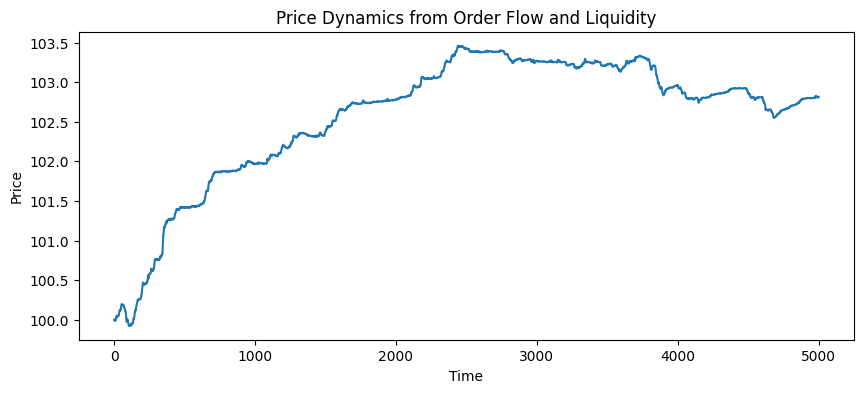

In [10]:
plt.figure(figsize=(10,4))

plt.plot(prices)

plt.xlabel("Time")
plt.ylabel("Price")

plt.title("Price Dynamics from Order Flow and Liquidity")

plt.show()

## Summary

Trong notebook này chúng ta đã nghiên cứu
vai trò của liquidity trong thị trường.

Các kết quả chính:

- limit order book chứa liquidity ở nhiều mức giá
- market orders tiêu thụ liquidity
- trade size ảnh hưởng tới price impact
- liquidity hấp thụ order flow

Điều này giải thích tại sao:

persistent order flow
không nhất thiết tạo ra persistent price trends.

Trong notebook tiếp theo,
chúng ta sẽ nghiên cứu vai trò của
**market makers và inventory risk**
trong việc cung cấp liquidity cho thị trường.